# Hubungan Diskon terhadap Volume Penjualan

## Metodologi

1. Menghitung total transaksi dan jumlah produk terjual pada setiap tingkat diskon.
2. Memfilter data untuk transaksi di atas 20.
3. Menampilkan hubungan antara tingkat diskon dengan volume penjualan dalam bentuk grafik.

## Persiapan Data dan Library

Mengimpor library yang dibutuhkan dan memuat dataset untuk proses analisis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore', category=FutureWarning)

df = pd.read_csv('superstore_2017.csv')

## Hitung Total Transaksi dan Jumlah Produk Terjual

Data dikelompokkan berdasarkan kategori dan tingkat diskon, kemudian dihitung total transaksi dan jumlah produk terjual.

In [2]:
df_agg = df.groupby(['category', 'discount']).agg(transaction=('order_id', 'count'), quantity=('quantity', 'sum')).astype(int)
df_agg.index = df_agg.index.set_levels(df_agg.index.levels[1].astype(int), level=1)

df_agg

transaction  quantity
category        discount                       
Furniture       0                 274       963
                10                 25        91
                15                 16        71
                20                204       707
                30                 67       257
                32                 11        33
                40                 24        93
                45                  4        15
                50                 15        54
                60                 39       118
                70                  7        35
Office Supplies 0                1033      3966
                10                  1         2
                20                736      2752
                70                125       484
                80                107       472
Technology      0                 282      1115
                10                  2         5
                20                282      1014
                30                  1         2
                40                 45       184
                50                  4        10
                70                  6        22

## Filter Data untuk Transaksi di Atas 20

Data difilter dengan hanya menyertakan tingkat diskon yang memiliki total transaksi diatas 20.

In [3]:
df_agg = df_agg[df_agg['transaction'] > 20]

df_agg

transaction  quantity
category        discount                       
Furniture       0                 274       963
                10                 25        91
                20                204       707
                30                 67       257
                40                 24        93
                60                 39       118
Office Supplies 0                1033      3966
                20                736      2752
                70                125       484
                80                107       472
Technology      0                 282      1115
                20                282      1014
                40                 45       184

## Visualisasi Data

Menampilkan volume penjualan per tingkat diskon untuk semua kategori.

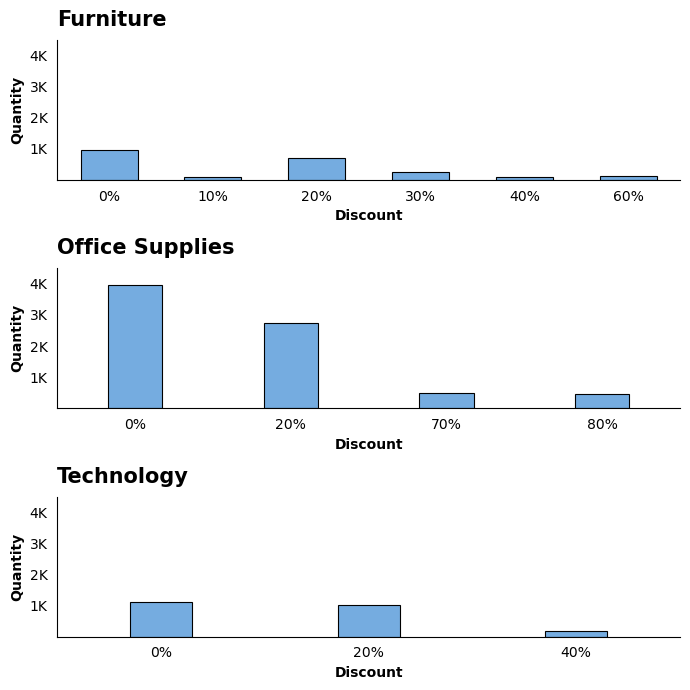

In [4]:
categories = df_agg.index.levels[0].tolist()
data = [df_agg.loc[category] for category in categories]

fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(7,7))

title_dict = {'size':15,
              'weight':'bold',
              'color':'black',
              'loc':'left',
              'pad':10,
              'rotation':0,
              'family':plt.rcParams['font.family'],
              'alpha':1}

label_dict = {'x':
              {'size':10,
              'weight':'bold',
              'color':'black',
              'loc':'center',
              'rotation':0,
              'family':plt.rcParams['font.family'],
              'alpha':1},
              
              'y':
              {'size':10,
              'weight':'bold',
              'color':'black',
              'loc':'center',
              'rotation':90,
              'family':plt.rcParams['font.family'],
              'alpha':1}}

for i in range(len(ax)):
    df_plot = data[i]
    
    patch = sns.barplot(x=df_plot.index, y=df_plot['quantity'], ax=ax[i], color='#63adf2', ec='black', lw=0.8, alpha=1)
    
    if i == 0:
        for bar in patch.patches:
            bar.set_width(0.55)
            bar.set_xy((bar.get_xy()[0] + 0.125, 0))
    elif i == 1:
        for bar in patch.patches:
            bar.set_width(0.35)
            bar.set_xy((bar.get_xy()[0] + 0.225, 0))
    else:
        for bar in patch.patches:
            bar.set_width(0.3)
            bar.set_xy((bar.get_xy()[0] + 0.25, 0))
    
    ax[i].set_title(f'{categories[i]}', **title_dict)
    ax[i].set_xlabel('Discount', **label_dict['x'])
    ax[i].set_ylabel('Quantity', **label_dict['y'])
        
    ax[i].set_ylim(0, 4_500)
    ax[i].set_yticks(ticks=ax[i].get_yticks()[1:-1])
    ax[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'{y/1_000:.0f}K'))
    
    labels = [f'{discount}%' for discount in df_plot.index]
    ax[i].set_xticklabels(labels=labels)
    
    ax[i].tick_params(which='major', axis='both', colors='black', left=False, bottom=False)
        
    sns.despine(left=False, top=True, right=True, bottom=False, ax=ax[i])

plt.tight_layout()
plt.show()